# Proyek Akhir: Menyelesaikan Permasalahan Departemen Human Resources (HR)

- **Nama:** Azizah Khusnul Fauziah
- **Email:** azizahkhusnulf@gmail.com
- **Id Dicoding:** azizah_khf

## Business Understanding

Perusahaan Jaya Jaya Maju mengalami permasalahan tingginya angka **attrition** (resign) karyawan yang berdampak pada biaya rekrutmen, produktivitas, dan stabilitas tim. Tujuan proyek ini adalah:
1. Mengidentifikasi faktor-faktor utama yang mendorong karyawan resign.
2. Membangun model prediktif untuk mengidentifikasi karyawan yang berisiko resign.
3. Memberikan rekomendasi berbasis data kepada manajemen HR.

## Persiapan

In [1]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load data
data = pd.read_csv("employee_data.csv")
data.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


## Data Understanding

Tahap ini bertujuan untuk memahami struktur data, tipe data, distribusi awal, dan mengidentifikasi potensi masalah sebelum analisis lebih lanjut.

In [3]:
# Informasi Dasar Dataset
print(f'Jumlah baris   : {data.shape[0]:,}')
print(f'Jumlah kolom   : {data.shape[1]}')
data.info()

Jumlah baris   : 1,470
Jumlah kolom   : 35
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement      

In [4]:
# Statistik Deskriptif Kolom Numerik
data.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
EmployeeId,1470.0,735.50,424.50,1.0,368.25,735.5,1102.75,1470.0
Age,1470.0,36.92,9.14,18.0,30.00,36.0,43.00,60.0
Attrition,1058.0,0.17,0.38,0.0,0.00,0.0,0.00,1.0
DailyRate,1470.0,802.49,403.51,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.19,8.11,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.91,1.02,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.00,0.00,1.0,1.00,1.0,1.00,1.0
EnvironmentSatisfaction,1470.0,2.72,1.09,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.89,20.33,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.73,0.71,1.0,2.00,3.0,3.00,4.0


In [5]:
# Statistik Deskriptif Kolom Kategorikal
data.describe(include=['object']).T

,count,unique,top,freq
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


In [6]:
# Pemeriksaan Missing Values
missing = data.isnull().sum()
missing

EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBalance               0
YearsAtC

Terdapat missing values pada kolom Attrition (NaN) sebanyak 412 baris

In [7]:
# Pemeriksaan Duplikasi Data
dup_count = data.duplicated().sum()
print(f'Jumlah baris duplikat: {dup_count}')

Jumlah baris duplikat: 0


In [8]:
# Pemeriksaan Kolom Konstan (nilai tunggal)
print('Kolom dengan nilai konstan (hanya 1 nilai unik):')
konstan = [col for col in data.columns if data[col].nunique() == 1]
for col in konstan:
    print(f'  - {col}: nilai = {data[col].unique()[0]}')

print()
print('Kolom dengan kardinalitas rendah (nilai unik < 5):')
for col in data.select_dtypes(include=['int64', 'float64']).columns:
    n_unique = data[col].nunique()
    if n_unique < 5:
        print(f'  - {col}: {n_unique} nilai unik = {sorted(data[col].dropna().unique())}')

Kolom dengan nilai konstan (hanya 1 nilai unik):
  - EmployeeCount: nilai = 1
  - Over18: nilai = Y
  - StandardHours: nilai = 80

Kolom dengan kardinalitas rendah (nilai unik < 5):
  - Attrition: 2 nilai unik = [np.float64(0.0), np.float64(1.0)]
  - EmployeeCount: 1 nilai unik = [np.int64(1)]
  - EnvironmentSatisfaction: 4 nilai unik = [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  - JobInvolvement: 4 nilai unik = [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  - JobSatisfaction: 4 nilai unik = [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  - PerformanceRating: 2 nilai unik = [np.int64(3), np.int64(4)]
  - RelationshipSatisfaction: 4 nilai unik = [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  - StandardHours: 1 nilai unik = [np.int64(80)]
  - StockOptionLevel: 4 nilai unik = [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  - WorkLifeBalance: 4 nilai unik = [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [9]:
# Distribusi Target Variable (Attrition)
print('Distribusi Attrition (data berlabel):')
labeled = data[data['Attrition'].notnull()]
attrition_count = labeled['Attrition'].value_counts()
attrition_pct = labeled['Attrition'].value_counts(normalize=True).mul(100).round(1)

summary = pd.DataFrame({'Jumlah': attrition_count, 'Persentase (%)': attrition_pct})
print(summary)

Distribusi Attrition (data berlabel):
           Jumlah  Persentase (%)
Attrition                        
0.0           879            83.1
1.0           179            16.9


Data tidak seimbang (imbalanced)


## Data Preprocessing

Berdasarkan hasil Data Understanding, beberapa langkah preprocessing yang perlu dilakukan adalah:
1. Menghapus kolom konstan (tidak memiliki nilai analitik)
2. Menangani missing values pada kolom `Attrition` (dipisahkan sebagai data unlabeled)
3. Memeriksa dan menangani outlier
4. Encoding kolom kategorikal
5. Feature scaling (jika diperlukan)

In [10]:
# Hapus Kolom Tidak Informatif
kolom_dibuang = ['EmployeeId', 'EmployeeCount', 'Over18', 'StandardHours']
data_clean = data.drop(columns=kolom_dibuang, errors='ignore')

print(f'Kolom dihapus: {kolom_dibuang}')
print(f'Shape setelah penghapusan kolom: {data_clean.shape}')

Kolom dihapus: ['EmployeeId', 'EmployeeCount', 'Over18', 'StandardHours']
Shape setelah penghapusan kolom: (1470, 31)


beberapa kolom yang dihapus adalah:
* Kolom konstan dari hasil pemeriksaan: EmployeeCount, Over18, StandardHours
* Kolom ID karena tidak memiliki nilai prediktif

In [11]:
# Identifikasi Tipe Kolom
num_cols = data_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = data_clean.select_dtypes(include=['object']).columns.tolist()

# Memisahkan target dari list fitur
if 'Attrition' in cat_cols:
    cat_cols.remove('Attrition')

print(f'Kolom Numerikal ({len(num_cols)}): {num_cols}')
print(f'Kolom Kategorikal ({len(cat_cols)}): {cat_cols}')

Kolom Numerikal (24): ['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Kolom Kategorikal (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [12]:
# Pemeriksaan missing values di kolom fitur lain (setelah penghapusan kolom konstan)
fitur_missing = data_clean.drop(columns=['Attrition']).isnull().sum()
fitur_missing = fitur_missing[fitur_missing > 0]
print(fitur_missing)

Series([], dtype: int64)


In [13]:
# Pemeriksaan Outlier (IQR Method pada kolom numerikal kontinu)
kolom_kontinu = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
                  'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
                  'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany',
                  'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
kolom_kontinu = [c for c in kolom_kontinu if c in data_clean.columns]

outlier_summary = []
for col in kolom_kontinu:
    Q1 = data_clean[col].quantile(0.25)
    Q3 = data_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((data_clean[col] < lower) | (data_clean[col] > upper)).sum()
    outlier_summary.append({'Kolom': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                              'Lower Bound': lower, 'Upper Bound': upper,
                              'Jumlah Outlier': n_outlier,
                              'Persentase (%)': round(n_outlier/len(data_clean)*100, 2)})

outlier_df = pd.DataFrame(outlier_summary).set_index('Kolom')
display(outlier_df[['Jumlah Outlier', 'Persentase (%)']].query('`Jumlah Outlier` > 0'))

,Jumlah Outlier,Persentase (%)
Kolom,,
MonthlyIncome,114,7.76
NumCompaniesWorked,52,3.54
TotalWorkingYears,63,4.29
TrainingTimesLastYear,238,16.19
YearsAtCompany,104,7.07
YearsInCurrentRole,21,1.43
YearsSinceLastPromotion,107,7.28
YearsWithCurrManager,14,0.95


* Outlier pada data HR bisa merupakan informasi penting (contohnya: karyawan senior)
* Pada pengolahan data ini Outlier TIDAK dihapus, karena data ini valid secara bisnis.
* Kolom dengan skala ordinal/biner tidak dicek outlier karena sudah terbatas range-nya


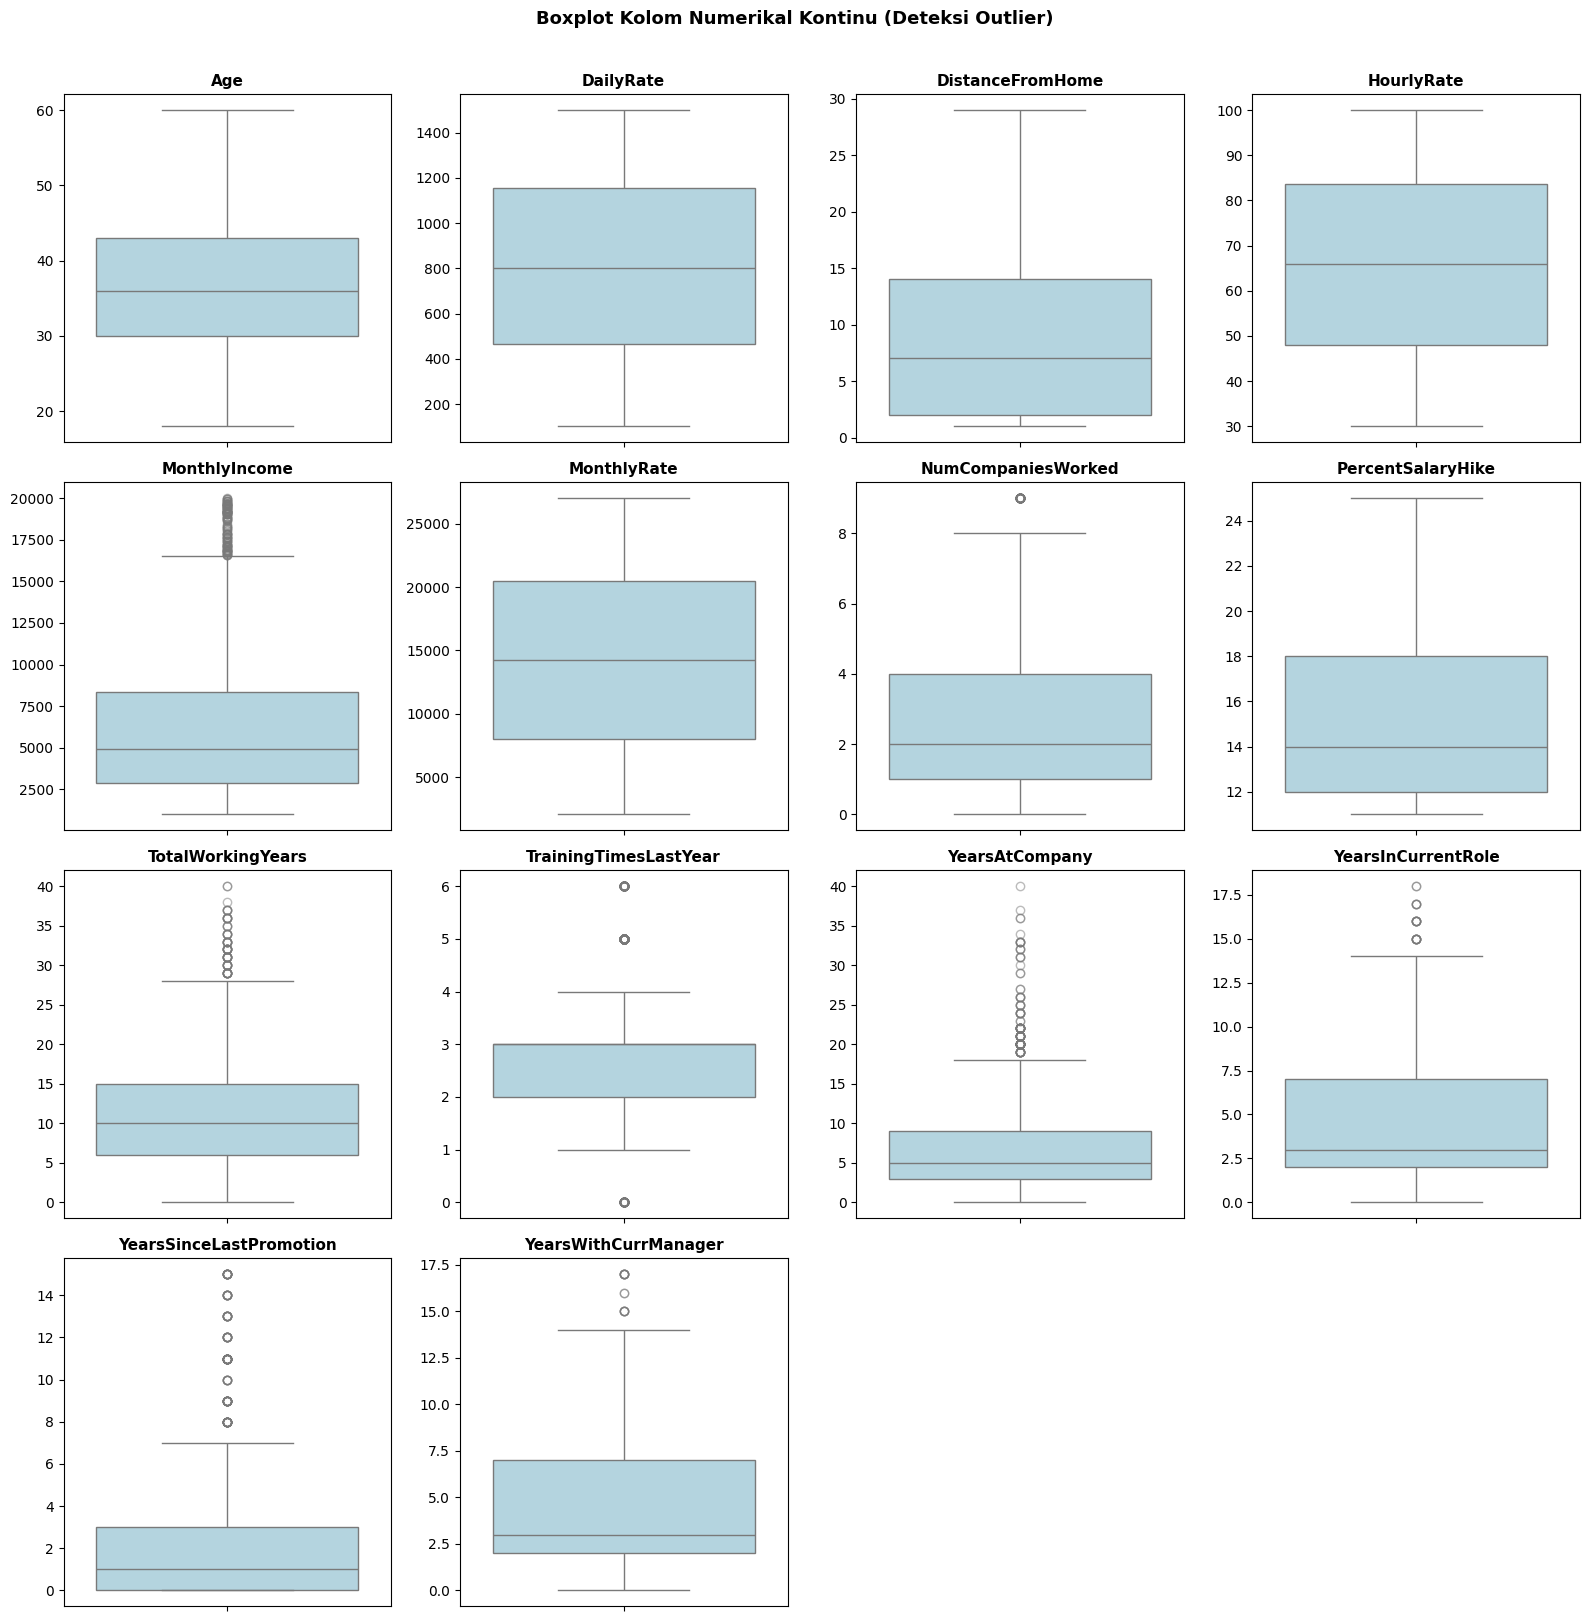

In [14]:
# Visualisasi Outlier (Boxplot Semua Kolom Numerikal Kontinu)
n_cols = 4
n_rows = (len(kolom_kontinu) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(kolom_kontinu):
    sns.boxplot(y=data_clean[col], ax=axes[i], color='lightblue', flierprops=dict(marker='o', color='red', alpha=0.5))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('')

for j in range(len(kolom_kontinu), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot Kolom Numerikal Kontinu (Deteksi Outlier)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA)

EDA dilakukan secara sistematis untuk memahami pola data sebelum modeling. EDA dibagi menjadi:
- **EDA Univariate Numerikal**: distribusi setiap fitur numerik
- **EDA Univariate Kategorikal**: distribusi setiap fitur kategorikal
- **EDA Multivariate**: hubungan antar fitur dan hubungan fitur dengan target (Attrition)

> Seluruh EDA dilakukan pada **data berlabel** saja untuk menghindari data leakage dan agar insight relevan dengan target.

In [15]:
# Mengunakan data berlabel untuk EDA
df_eda = data_clean[data_clean['Attrition'].notnull()].copy()
print(f'Shape data berlabel untuk EDA: {df_eda.shape}')

Shape data berlabel untuk EDA: (1058, 31)


### EDA Univariate - Numerikal

Tujuan: Memahami distribusi setiap fitur numerik (normal, skewed, bimodal, dll.).

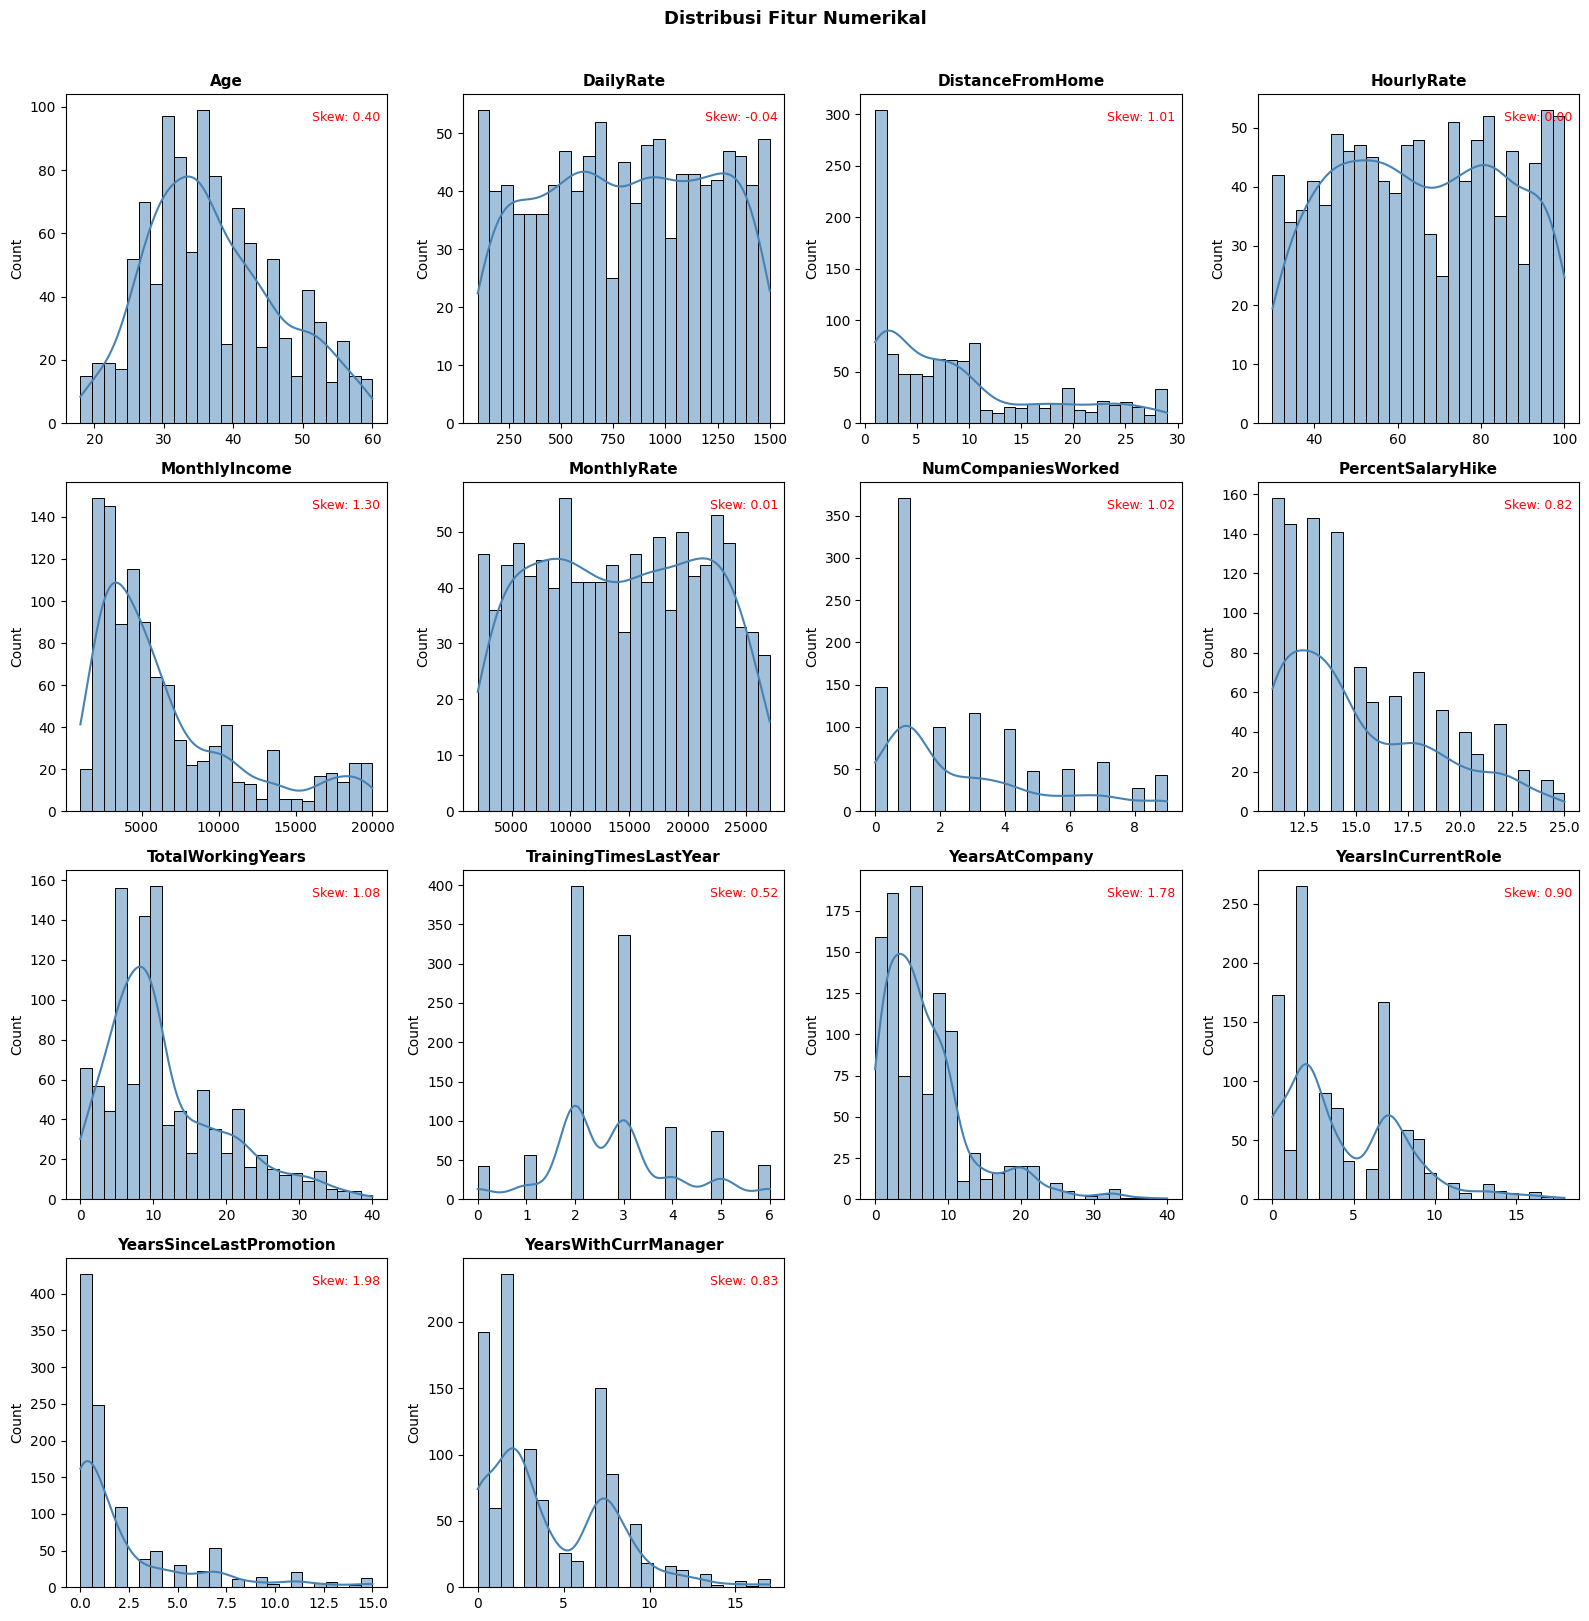

In [16]:
# Histogram + KDE untuk semua kolom numerikal kontinu
n_cols = 4
n_rows = (len(kolom_kontinu) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(kolom_kontinu):
    if col in df_eda.columns:
        sns.histplot(df_eda[col], ax=axes[i], kde=True, color='steelblue', bins=25)
        axes[i].set_title(col, fontsize=11, fontweight='bold')
        axes[i].set_xlabel('')
        skew = df_eda[col].skew()
        axes[i].text(0.98, 0.95, f'Skew: {skew:.2f}', transform=axes[i].transAxes,
                     ha='right', va='top', fontsize=9, color='red')

for j in range(len(kolom_kontinu), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerikal', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Insight:
Kolom dengan skewness tinggi (skew>1): ['DistanceFromHome', 'MonthlyIncome', 'NumCompaniesWorked', 'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion']

Kolom-kolom ini memiliki distribusi miring, artinya terdapat karyawan dengan nilai ekstrem.

### EDA Univariate - Kategorikal

Tujuan: Memahami distribusi setiap fitur kategorikal.

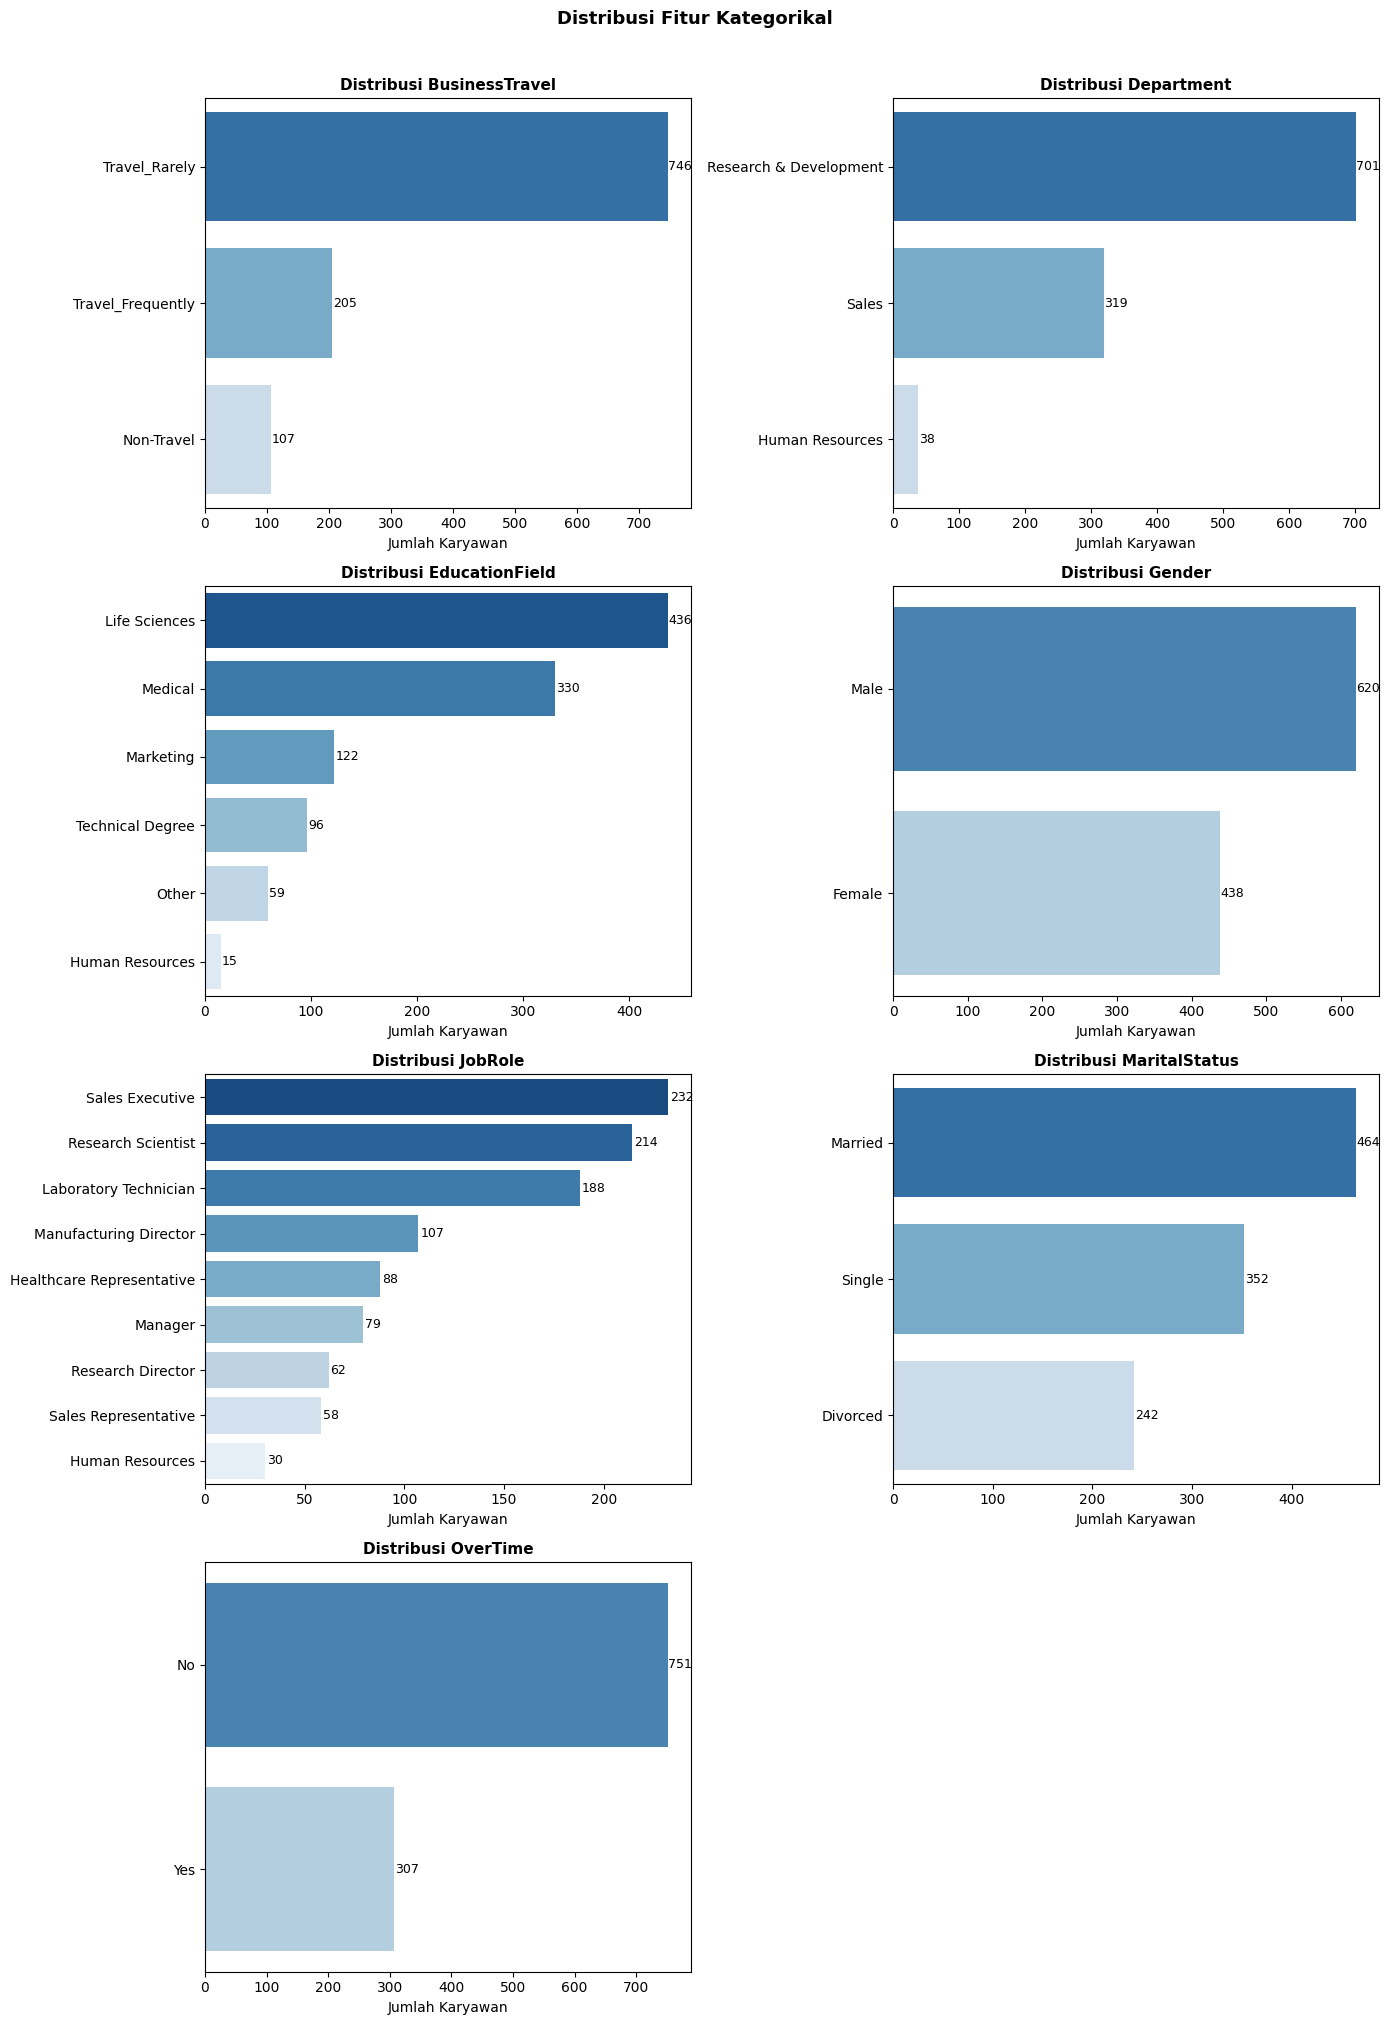

In [17]:
# Count plot untuk setiap kolom kategorikal
n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if col in df_eda.columns:
        order = df_eda[col].value_counts().index
        sns.countplot(data=df_eda, y=col, ax=axes[i], order=order, palette='Blues_r')
        axes[i].set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Jumlah Karyawan')
        axes[i].set_ylabel('')
        for p in axes[i].patches:
            axes[i].annotate(f'{int(p.get_width())}',
                             (p.get_width()+1, p.get_y()+p.get_height()/2),
                             va='center', fontsize=9)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### EDA Multivariate - Numerikal vs Target (Attrition)

Tujuan: Mengidentifikasi fitur numerikal mana yang paling membedakan karyawan yang resign vs tidak.

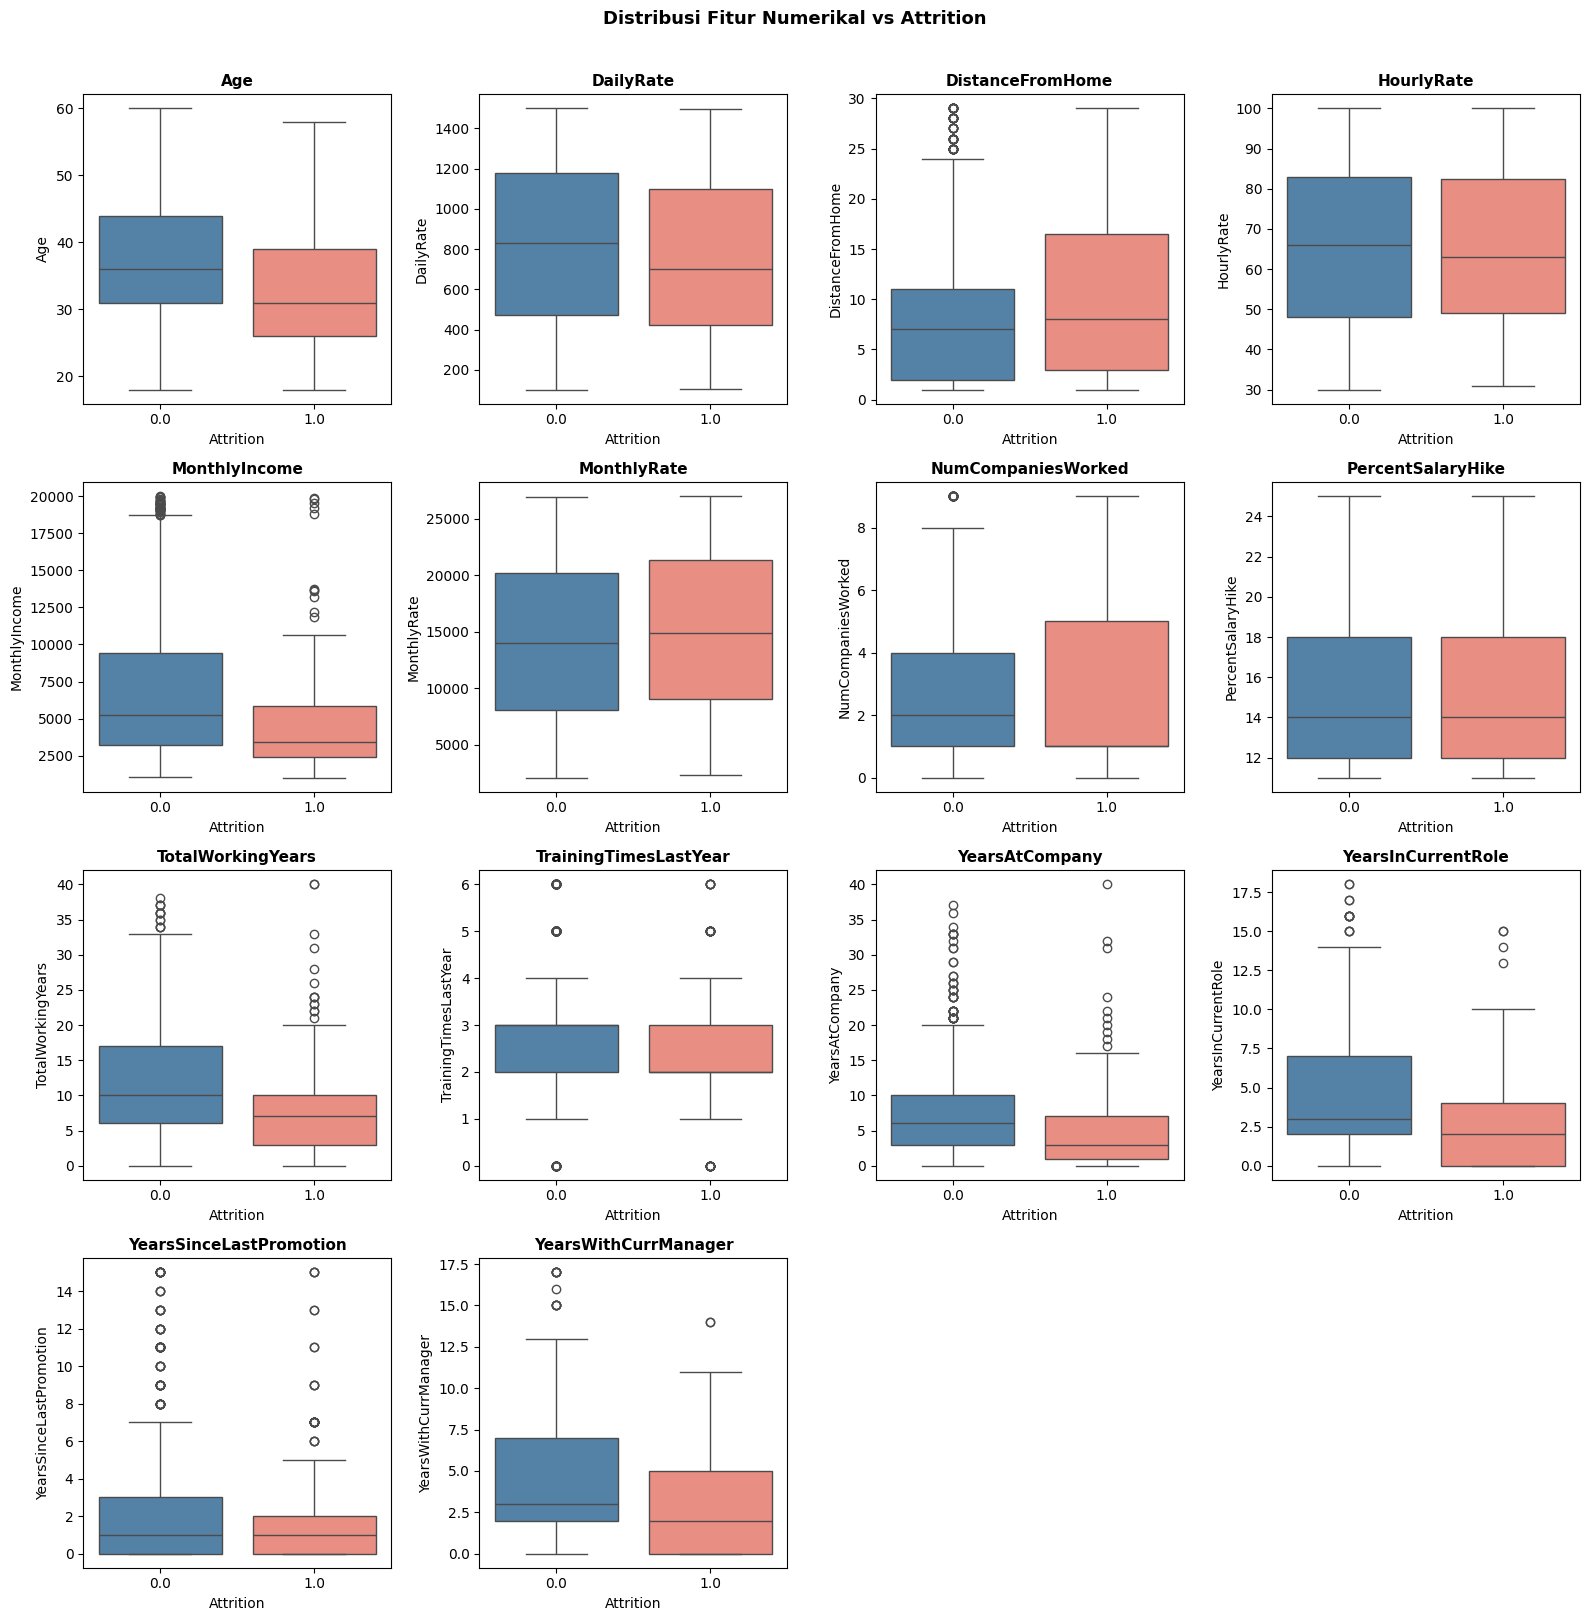

In [18]:
# Boxplot setiap fitur numerikal vs Attrition
n_cols = 4
n_rows = (len(kolom_kontinu) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(kolom_kontinu):
    if col in df_eda.columns:
        sns.boxplot(data=df_eda, x='Attrition', y=col, ax=axes[i],
                    palette={'Yes': 'salmon', 'No': 'steelblue', '1.0': 'salmon', '0.0': 'steelblue'})
        axes[i].set_title(col, fontsize=11, fontweight='bold')

for j in range(len(kolom_kontinu), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerikal vs Attrition', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### EDA Multivariate - Korelasi Antar Fitur Numerikal

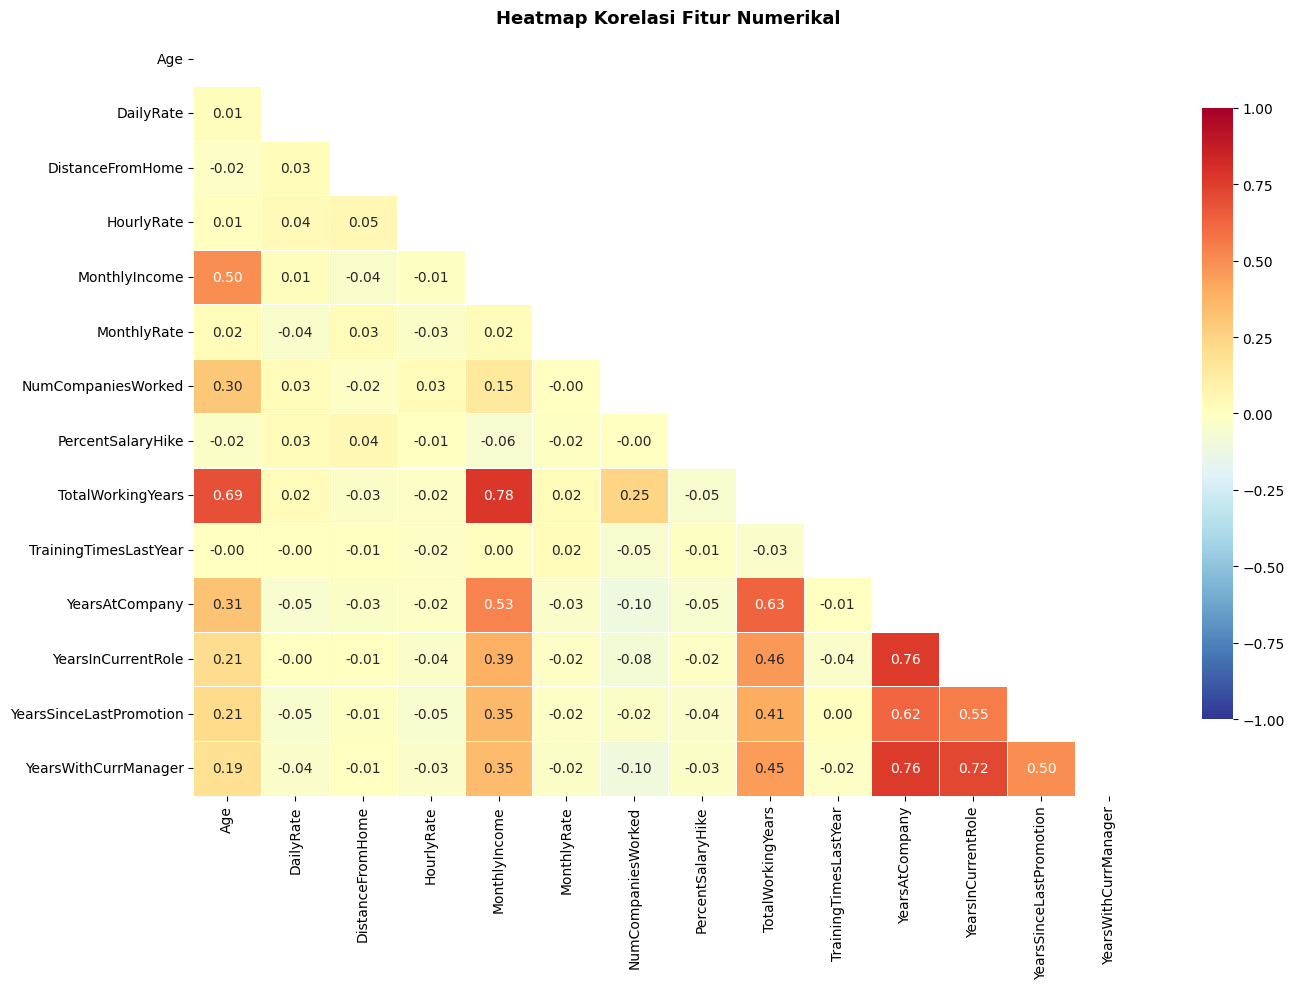

In [19]:
# Heatmap korelasi
kolom_num_eda = [c for c in kolom_kontinu if c in df_eda.columns]
corr_matrix = df_eda[kolom_num_eda].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r',
            mask=mask, center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Fitur Numerikal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### EDA Multivariate - Analisis Ordinal (Skala 1-4/1-5 vs Attrition)

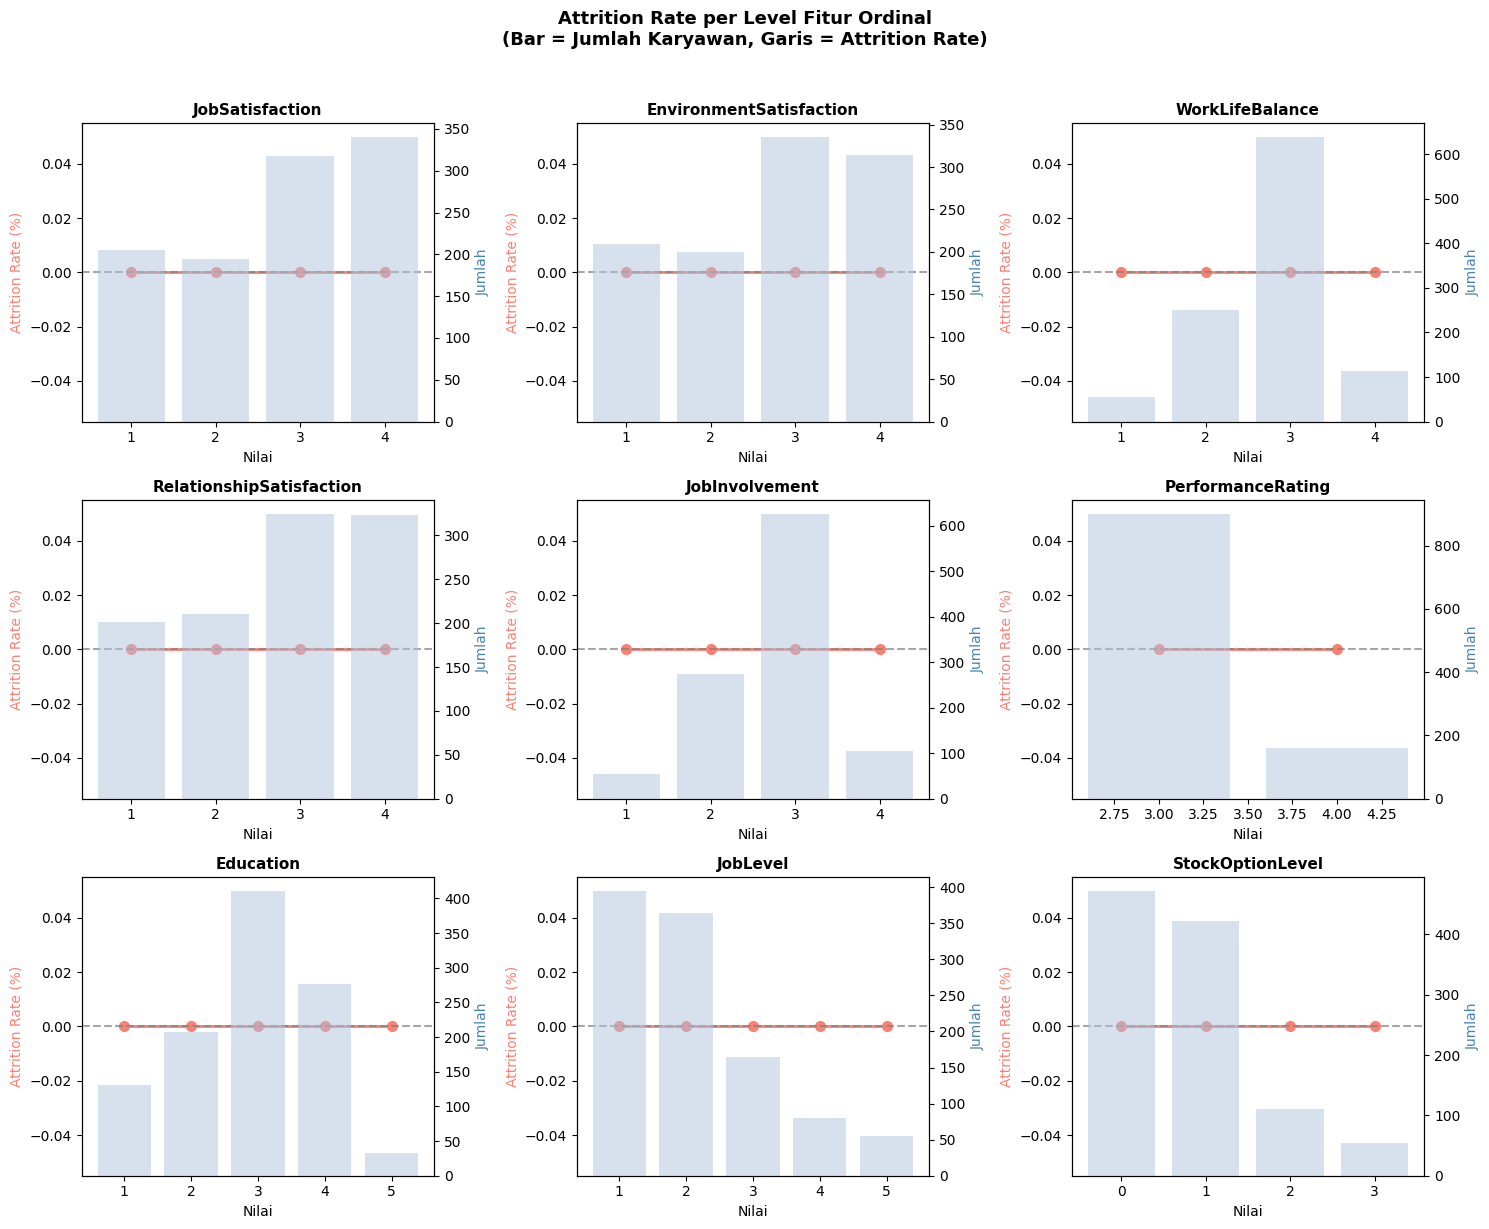

In [20]:
# Kolom ordinal/rating
kolom_ordinal = ['JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance',
                  'RelationshipSatisfaction', 'JobInvolvement', 'PerformanceRating',
                  'Education', 'JobLevel', 'StockOptionLevel']
kolom_ordinal = [c for c in kolom_ordinal if c in df_eda.columns]

n_cols = 3
n_rows = (len(kolom_ordinal) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(kolom_ordinal):
    rate = df_eda.groupby(col)['Attrition'].apply(lambda x: (x=='Yes').mean()*100).reset_index()
    rate.columns = [col, 'AttritionRate']

    count = df_eda[col].value_counts().sort_index()
    ax2 = axes[i].twinx()

    ax2.bar(count.index, count.values, color='lightsteelblue', alpha=0.5, label='Jumlah')
    axes[i].plot(rate[col], rate['AttritionRate'], 'o-', color='salmon', linewidth=2, markersize=7, label='Attrition %')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Attrition Rate (%)', color='salmon')
    ax2.set_ylabel('Jumlah', color='steelblue')
    axes[i].axhline(y=df_eda['Attrition'].eq('Yes').mean()*100, color='gray', linestyle='--', alpha=0.7)

for j in range(len(kolom_ordinal), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Attrition Rate per Level Fitur Ordinal\n(Bar = Jumlah Karyawan, Garis = Attrition Rate)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### EDA - Analisis Overtime vs Attrition

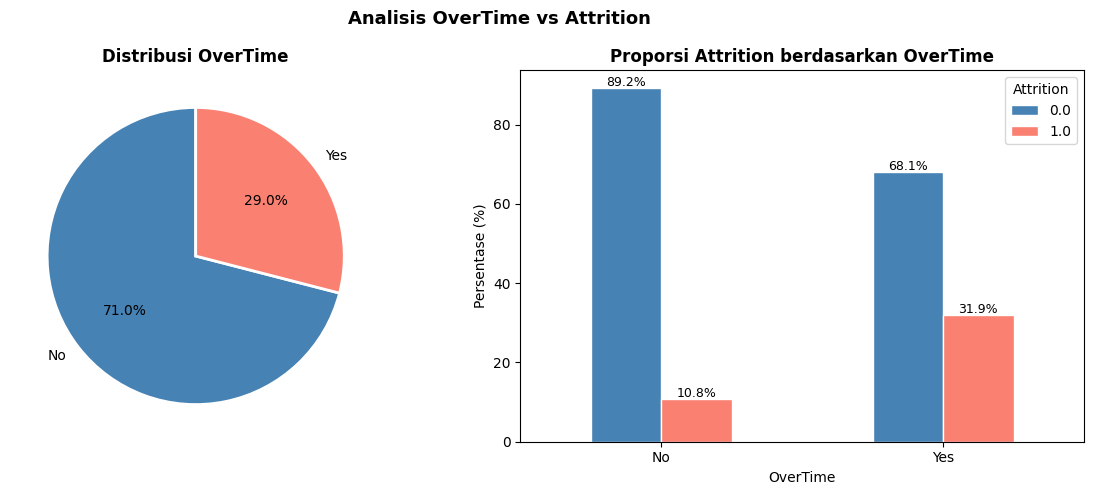

In [21]:
# Overtime adalah salah satu faktor HR yang sering sangat berpengaruh
if 'OverTime' in df_eda.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Distribusi Overtime
    ot_count = df_eda['OverTime'].value_counts()
    axes[0].pie(ot_count, labels=ot_count.index, autopct='%1.1f%%',
                colors=['steelblue', 'salmon'], startangle=90,
                wedgeprops=dict(edgecolor='white', linewidth=2))
    axes[0].set_title('Distribusi OverTime', fontweight='bold')

    # Attrition rate by Overtime
    ot_attr = df_eda.groupby(['OverTime', 'Attrition']).size().unstack(fill_value=0)
    ot_attr_pct = ot_attr.div(ot_attr.sum(axis=1), axis=0) * 100
    ot_attr_pct.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], edgecolor='white', rot=0)
    axes[1].set_title('Proporsi Attrition berdasarkan OverTime', fontweight='bold')
    axes[1].set_xlabel('OverTime')
    axes[1].set_ylabel('Persentase (%)')
    axes[1].legend(title='Attrition')
    for p in axes[1].patches:
        axes[1].annotate(f'{p.get_height():.1f}%',
                         (p.get_x()+p.get_width()/2, p.get_height()+0.5),
                         ha='center', fontsize=9)

    plt.suptitle('Analisis OverTime vs Attrition', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### RINGKASAN INSIGHT EDA

Berdasarkan hasil EDA yang telah dilakukan:

1. DISTRIBUSI TARGET:
   - Data tidak seimbang: Attrition=Yes jauh lebih sedikit
   - Perlu penanganan class imbalance saat modeling

2. FITUR NUMERIKAL:
   - YearsAtCompany, TotalWorkingYears, MonthlyIncome: karyawan resign
     cenderung memiliki nilai lebih rendah
   - YearsSinceLastPromotion tinggi berpotensi meningkatkan attrition

3. FITUR KATEGORIKAL:
   - OverTime = Yes: attrition rate jauh lebih tinggi dari rata-rata
   - Department dan JobRole tertentu memiliki attrition rate lebih tinggi

4. FITUR ORDINAL:
   - JobSatisfaction rendah (1-2) : attrition rate tinggi
   - WorkLifeBalance rendah : attrition rate tinggi
   - StockOptionLevel 0 : attrition rate tinggi


## Modeling

Berdasarkan insight EDA:
- Data tidak seimbang, tindakan selanjutnya adalah menggunakan `class_weight='balanced'` atau SMOTE
- Algoritma: Random Forest (baseline) + XGBoost (pembanding) karena keduanya robust dan bisa handle mixed features
- Evaluasi utama: **Recall** untuk kelas Attrition=Yes (lebih penting mendeteksi yang resign)

In [22]:
# Pisahkan data labeled dan unlabeled
data_labeled   = data_clean[data_clean['Attrition'].notnull()].copy()
data_unlabeled = data_clean[data_clean['Attrition'].isnull()].copy()

# Pisahkan X dan y
X = data_labeled.drop(columns=['Attrition'])
y_raw = data_labeled['Attrition']

# Periksa nilai unik di y_raw untuk memastikan
print(f'Nilai unik di y_raw: {y_raw.unique()}')

# Encode target: 1.0=1, 0.0=0
y = y_raw.map({1.0: 1, 0.0: 0})

# Jaga-jaga jika masih ada NaN
if y.isnull().any():
    print("Warning: Ada nilai NaN setelah mapping. Mengganti NaN dengan 0.")
    y = y.fillna(0)
y = y.astype(int)

print(f'Shape X: {X.shape}')
print(f'Distribusi y: {dict(y.value_counts())}')

Nilai unik di y_raw: [1. 0.]
Shape X: (1058, 30)
Distribusi y: {0: np.int64(879), 1: np.int64(179)}


In [23]:
# Encoding fitur kategorikal menggunakan get_dummies
X_encoded = pd.get_dummies(X, drop_first=True)
X_unlabeled_encoded = pd.get_dummies(data_unlabeled.drop(columns=['Attrition']), drop_first=True)

# Selaraskan kolom
X_unlabeled_encoded = X_unlabeled_encoded.reindex(columns=X_encoded.columns, fill_value=0)

print(f'Shape X_encoded: {X_encoded.shape}')
print(f'Shape X_unlabeled_encoded: {X_unlabeled_encoded.shape}')

Shape X_encoded: (1058, 44)
Shape X_unlabeled_encoded: (412, 44)


In [24]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

# Train-Test Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Train - Attrition=Yes: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Test  - Attrition=Yes: {y_test.sum()} ({y_test.mean()*100:.1f}%)')

Train size: 846 | Test size: 212
Train - Attrition=Yes: 143 (16.9%)
Test  - Attrition=Yes: 36 (17.0%)


In [25]:
# Model 1: Random Forest dengan class_weight balanced
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Threshold tuning: default 0.5 tidak optimal untuk imbalanced data
# Gunakan threshold yang memaksimalkan F1 pada data train
y_prob_train = rf_model.predict_proba(X_train)[:, 1]
thresholds = np.arange(0.2, 0.7, 0.05)
f1_scores = [f1_score(y_train, (y_prob_train >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f'Best threshold (Random Forest): {best_threshold:.2f}')

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_rf, target_names=['No (Bertahan)', 'Yes (Resign)']))

Best threshold (Random Forest): 0.50
               precision    recall  f1-score   support

No (Bertahan)       0.88      0.95      0.92       176
 Yes (Resign)       0.64      0.39      0.48        36

     accuracy                           0.86       212
    macro avg       0.76      0.67      0.70       212
 weighted avg       0.84      0.86      0.84       212



In [26]:
# Model 2: Gradient Boosting
from sklearn.utils.class_weight import compute_sample_weight

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)
sample_weights = compute_sample_weight('balanced', y_train)
gb_model.fit(X_train, y_train, sample_weight=sample_weights)

y_prob_gb = gb_model.predict_proba(X_test)[:, 1]
y_pred_gb = (y_prob_gb >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_gb, target_names=['No (Bertahan)', 'Yes (Resign)']))

               precision    recall  f1-score   support

No (Bertahan)       0.89      0.91      0.90       176
 Yes (Resign)       0.50      0.44      0.47        36

     accuracy                           0.83       212
    macro avg       0.69      0.68      0.68       212
 weighted avg       0.82      0.83      0.83       212




## Evaluation

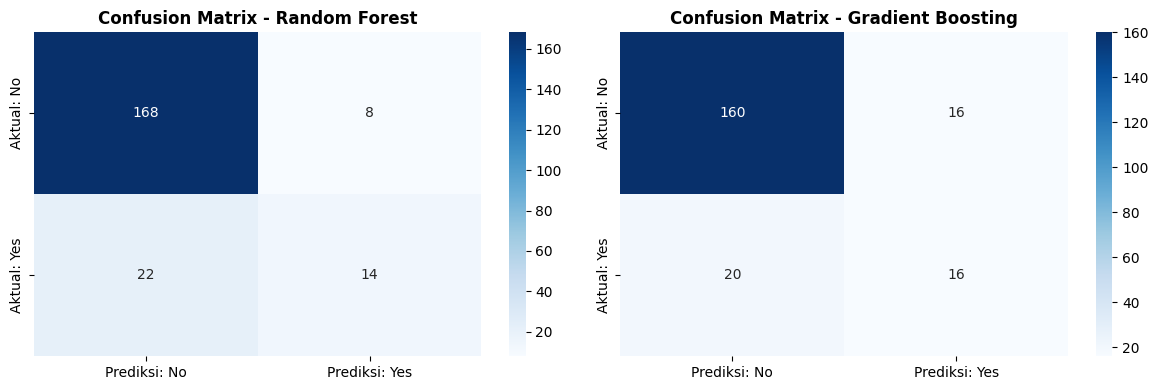

In [27]:
# Confusion Matrix - kedua model
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
models = [('Random Forest', y_pred_rf), ('Gradient Boosting', y_pred_gb)]

for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Prediksi: No', 'Prediksi: Yes'],
                yticklabels=['Aktual: No', 'Aktual: Yes'])
    ax.set_title(f'Confusion Matrix - {name}', fontweight='bold')

plt.tight_layout()
plt.show()

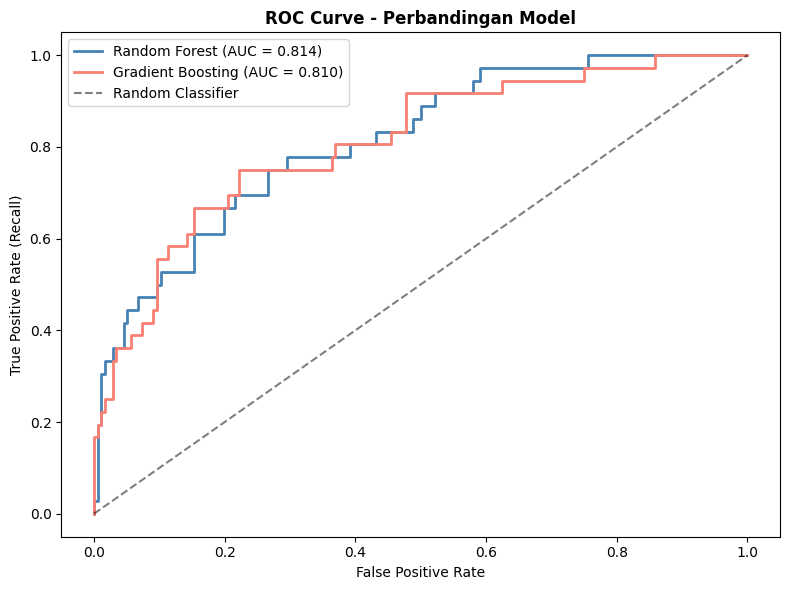

In [28]:
# ROC Curve perbandingan
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_gb = roc_auc_score(y_test, y_prob_gb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='steelblue', lw=2)
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.3f})', color='salmon', lw=2)
plt.plot([0,1], [0,1], 'k--', alpha=0.5, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Perbandingan Model', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Pilih model terbaik
best_model_name = 'Random Forest' if auc_rf >= auc_gb else 'Gradient Boosting'
best_model = rf_model if auc_rf >= auc_gb else gb_model
best_prob = y_prob_rf if auc_rf >= auc_gb else y_prob_gb

Model yang dipilih adalah Random Forest dengan hasil AUC = 0.814

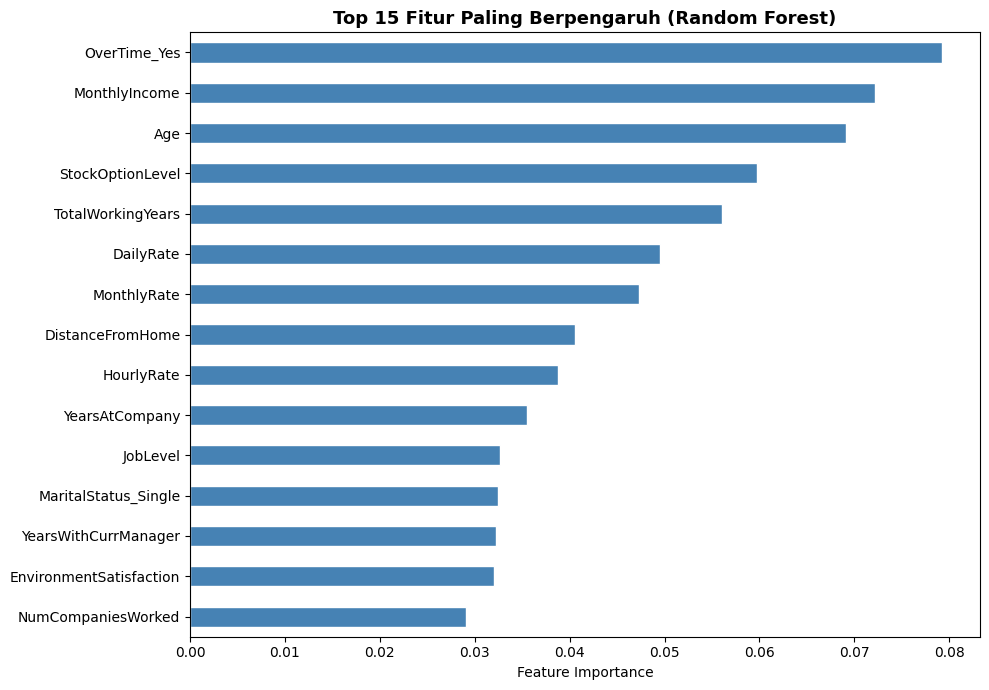

In [29]:
# Feature Importance dari model terbaik
importances = pd.Series(best_model.feature_importances_, index=X_encoded.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
top15.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title(f'Top 15 Fitur Paling Berpengaruh ({best_model_name})', fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

Top 5 faktor terbesar penyebab attrition:
  1. OverTime_Yes: 0.0793
  2. MonthlyIncome: 0.0721
  3. Age: 0.0692
  4. StockOptionLevel: 0.0598
  5. TotalWorkingYears: 0.0560

In [30]:
# Cross-Validation untuk validasi model yang lebih robust
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_rf = cross_val_score(rf_model, X_encoded, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print('Cross-Validation AUC (5-fold) - Random Forest:')
print(f'  Scores: {cv_scores_rf.round(3)}')
print(f'  Mean: {cv_scores_rf.mean():.3f} ± {cv_scores_rf.std():.3f}')

Cross-Validation AUC (5-fold) - Random Forest:
  Scores: [0.771 0.755 0.79  0.782 0.797]
  Mean: 0.779 ± 0.015



## Prediksi Data Unlabeled & Export

In [31]:
# Prediksi data unlabeled menggunakan model terbaik
pred_unlabeled = best_model.predict(X_unlabeled_encoded)
pred_proba_unlabeled = best_model.predict_proba(X_unlabeled_encoded)[:, 1]

# Buat data_dashboard
data_dashboard = data_clean.copy()
data_dashboard.loc[data_dashboard['Attrition'].isnull(), 'Attrition'] = \
    pd.Series(pred_unlabeled, index=data_unlabeled.index).map({1: 'Yes', 0: 'No'})

# Karyawan dengan hasil prediksi yang asalnya NaN
data_dashboard['Attrition'] = data_dashboard['Attrition'].map(
    lambda x: 'Yes' if x == 1 or x == 1.0 else ('No' if x == 0 or x == 0.0 else x)
)

# Simpan
data_dashboard.to_csv('JayaJayaMaju_Dashboard_Data.csv', index=False)
print(f'Data berhasil diekspor! Shape: {data_dashboard.shape}')
print(f"Distribusi Attrition final:\n{data_dashboard['Attrition'].value_counts()}")

Data berhasil diekspor! Shape: (1470, 31)
Distribusi Attrition final:
Attrition
No     1249
Yes     221
Name: count, dtype: int64


In [32]:
# Simpan model
joblib.dump(best_model, 'best_model.joblib')
joblib.dump(X_encoded.columns.tolist(), 'model_features.joblib')
print('Model dan feature list tersimpan.')

Model dan feature list tersimpan.


In [34]:
data_dashboard['OverTime'].value_counts()

OverTime
No     1054
Yes     416
Name: count, dtype: int64

In [38]:
# Mengambil daftar umur yang ada dan mengurutkannya
daftar_umur = data_dashboard['Age'].sort_values().unique()

# Menampilkan hasilnya
daftar_umur

array([18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60])

# Kesimpulan dan Rekomendasi


HASIL MODEL:
- Model terbaik: Random Forest
- AUC-ROC: 0.814 — kemampuan diskriminasi yang baik
- CV AUC Mean: 0.779 ± 0.015 — model stabil

FAKTOR UTAMA PENYEBAB ATTRITION (berdasarkan Feature Importance & EDA):
1. OverTime — Karyawan yang lembur memiliki attrition rate jauh lebih tinggi
2. MonthlyIncome — Gaji rendah berkorelasi kuat dengan resign
3. Age & YearsAtCompany — Karyawan muda & masa kerja pendek lebih berisiko
4. JobSatisfaction & WorkLifeBalance — Rendahnya kepuasan kerja mendorong resign
5. StockOptionLevel 0 — Kurangnya insentif jangka panjang meningkatkan attrition

REKOMENDASI KEPUTUSAN BISNIS
1. Evaluasi kebijakan lembur — batasi overtime & berikan kompensasi adil
2. Review struktur gaji terutama untuk posisi entry-level & junior
3. Program retensi untuk karyawan 0-2 tahun masa kerja
4. Survey kepuasan rutin & program peningkatan work-life balance
5. Perluasan program stock option/equity untuk karyawan loyal